In [1]:
import os
import yaml
import logging
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from pyspark.sql.functions import col, udf
from pyspark.sql.types import FloatType
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import GBTClassificationModel

from utils.spark_session import get_spark_session

from sklearn.metrics import classification_report,precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

spark = get_spark_session("08-evaluate-pipeline-artifacts")

In [2]:
test_path = os.path.join("..", "data", "train_test", "test.parquet")
config_path = os.path.join("..", "src", "config", "feature_config.yaml")
features_selected_path = os.path.join("..", "src", "features", "selected", "features_selected.yaml")
model_path = os.path.join("..", "models", "final_gbt_model")

In [3]:
df = spark.read.parquet(test_path)
with open(config_path, 'r') as f:
    feature_config = yaml.safe_load(f)
with open(features_selected_path, 'r') as f:
    selected_yaml = yaml.safe_load(f)


In [4]:
target_col = [k for k, v in feature_config.items() if isinstance(v, dict) and v.get("target")][0]
selected_features = selected_yaml.get("support_random_forest", [])
available_cols = [f.name for f in df.schema.fields]
feature_cols = [f for f in selected_features if f in available_cols]

In [5]:
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_test = assembler.transform(df.select(*(feature_cols + [target_col]))).select("features", col(target_col).alias("label"))

df_test.show()

+--------------------+-----+
|            features|label|
+--------------------+-----+
|[3.13043478260869...|    0|
|[1.36956521739130...|    0|
|[8.54347826086956...|    0|
|[1.82903225806451...|    0|
|[1.12580645161290...|    0|
|[0.006,0.006,186....|    0|
|[1.45806451612903...|    0|
|[3.00000000000000...|    0|
|[2.09032258064516...|    0|
|[2.76774193548387...|    0|
|[2.39354838709677...|    0|
|[1.92682926829268...|    0|
|[1.04878048780487...|    0|
|[3.43902439024390...|    0|
|[2.69268292682926...|    1|
|[2.26829268292682...|    0|
|[3.53658536585365...|    0|
|[3.65853658536585...|    0|
|[4.53658536585365...|    0|
|[4.63414634146341...|    0|
+--------------------+-----+
only showing top 20 rows



In [6]:
model = GBTClassificationModel.load(model_path)
predictions = model.transform(df_test)

In [7]:
extract_prob_1 = udf(lambda v: float(v[1]), FloatType())
predictions = predictions.withColumn("prob_1", extract_prob_1(col("probability")))

In [8]:
pred_pd = predictions.select("prob_1", "prediction", "label").toPandas()
probs = pred_pd["prob_1"].values
true_labels = pred_pd["label"].values

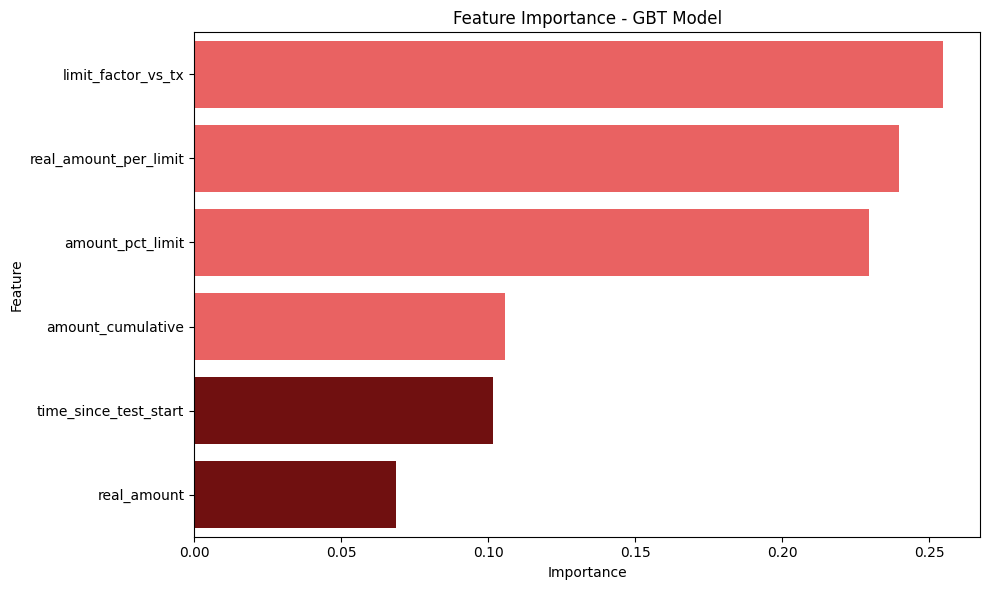

In [9]:
importances = model.featureImportances.toArray()
final_features = selected_features[:len(importances)]

assembler = VectorAssembler(inputCols=final_features, outputCol="features")
df_test = assembler.transform(df.select(*(final_features + [target_col])))
df_test = df_test.select("features", col(target_col).alias("label"))

engineered_features = [
    'real_amount_per_limit',
    'n_transactions_so_far',
    'amount_cumulative',
    'n_conversions_so_far',
    'pct_current_vs_total_session',
    'amount_pct_limit',
    'limit_factor_vs_tx'
]

feature_importance_df = pd.DataFrame({
    'feature': final_features,
    'importance': importances
})

feature_importance_df = feature_importance_df[feature_importance_df['importance'] > 0]

feature_importance_df['color'] = feature_importance_df['feature'].apply(
    lambda x: '#ff4c4c' if x in engineered_features else '#800000'
)

feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='importance',
    y='feature',
    data=feature_importance_df,
    palette=feature_importance_df['color'].tolist()
)
plt.title('Feature Importance - GBT Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [10]:
engineered_total = feature_importance_df[
    feature_importance_df['feature'].isin(engineered_features)
]['importance'].sum()

overall_total = feature_importance_df['importance'].sum()

engineered_percentage = engineered_total / overall_total * 100
print(f"Engineered features account for {engineered_percentage:.2f}% of total importance.")

Engineered features account for 82.97% of total importance.


In [11]:
precisions, recalls, thresholds = precision_recall_curve(true_labels, probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]
print(f"Best threshold (F1-score): {best_threshold:.4f}")

new_preds = (probs >= best_threshold).astype(int)

report = classification_report(true_labels, new_preds, digits=4)
print(report)

Best threshold (F1-score): 0.0412
              precision    recall  f1-score   support

           0     0.9008    0.8174    0.8571     21617
           1     0.5101    0.6788    0.5825      6056

    accuracy                         0.7870     27673
   macro avg     0.7055    0.7481    0.7198     27673
weighted avg     0.8153    0.7870    0.7970     27673



In [12]:
pred_pd['score'] = (pred_pd['prob_1'] * 1000).astype(int)

pred_pd['rank_score'] = pred_pd['score'].rank(method='first')

pred_pd['decil'] = pd.qcut(pred_pd['rank_score'], q=10, labels=False)

results = (
    pred_pd.groupby('decil').label.sum() / pred_pd.label.sum()
).reset_index()

results['decil'] += 1

results['offers'] = pred_pd[pred_pd.label == 1].groupby('decil').size()
results['total_items'] = pred_pd.groupby('decil').size().astype(int)
results['no_offers'] = results['total_items'] - results['offers']
results['score (>=)'] = round(pred_pd.groupby('decil').score.min(), 3)

results.fillna(0, inplace=True)

results.sort_values(by='decil', ascending=False, inplace=True)

results = results[['decil', 'score (>=)', 'offers', 'no_offers', 'total_items', 'label']]
results = results.rename(columns={'label': 'recall'})

results['recall'] = results['recall'].cumsum()
results['precision'] = results['offers'] / results['total_items']

results['no_offers'] = results['no_offers'].cumsum()
results['total_items'] = results['total_items'].cumsum()

results.reset_index(drop=True, inplace=True)
results

,decil,score (>=),offers,no_offers,total_items,recall,precision
0,10,179,1640,1128,2768,0.270806,0.592486
1,9,179,1341,2554,5535,0.492239,0.484640
2,8,37,1158,4163,8302,0.683454,0.418504
3,7,23,555,6375,11069,0.775099,0.200578
4,6,16,414,8728,13836,0.843461,0.149621
5,5,16,196,11300,16604,0.875826,0.070809
6,4,15,145,13922,19371,0.899769,0.052403
7,3,15,134,16555,22138,0.921896,0.048428
8,2,15,126,19196,24905,0.942701,0.045537
9,1,8,347,21617,27673,1.000000,0.125361


A tabela mostra a performance do modelo ao segmentar clientes em 10 decis com base em um score preditivo, onde **Decil 10 representa os clientes com maior score (maior probabilidade de conversão)**.

* **Decis superiores (10 a 8)** concentram os clientes com maior probabilidade de conversão, apresentando **maior precisão**. Contudo, como esses grupos contêm uma menor fração da base, o **recall acumulado** ainda é limitado — indicando que, embora os clientes desses decis sejam altamente qualificados, eles não representam a maioria dos casos positivos.

* **Decis intermediários e inferiores (7 a 1)** abrangem um número muito maior de clientes. Com isso, o modelo consegue **capturar praticamente todos os casos positivos** (recall atinge 100% no Decil 1), mas à custa de **baixa precisão** — ou seja, muitos falsos positivos. 


Dessa forma, **ações de marketing mais direcionadas devem priorizar os decis superiores**, que possuem maior concentração de clientes com perfil de conversão, otimizando o custo-benefício.


In [13]:
spark.stop()